← [Cómo se mide](11-como-se-mide.ipynb) · [Índice](00-indice.ipynb)

# 12 · Del modelo al robot

Entrenar produce un modelo de Keras. Lo que corre en el servicio es otra cosa.
Este documento cubre esa traducción, donde se pierde más de lo que parece.



## Estado vigente del proyecto (actualizado el 13 de agosto de 2026)

Esta serie conserva explicaciones y resultados históricos, pero la referencia
operativa actual es la siguiente:

- El sistema experto tiene **193 reglas**, CF estilo MYCIN, meta-reglas,
  encadenamiento hacia adelante y hacia atrás. Su voto usa OpenAI como
  proveedor principal, con heurísticas OpenCV que refinan atributos.
- El modelo local que participa en la decisión es **MobileNetV2 TFLite
  float32**, corrida `run_20260721_2129`; clasifica solo `plastico | vidrio`.
  MobileNetV3-Large INT8 está archivado como respaldo y **no emite votos**.
- En 1.000 capturas OV3660/QVGA, V2 obtuvo **71,60 %** de exactitud y
  **71,25 %** de macro-F1; V3 INT8 obtuvo 57,10 % y 57,09 %. La validación
  histórica de 98,43 % no describe por sí sola el rendimiento del robot.
- La ESP32-CAM toma tres fotos: se suman los seis votos válidos de ambas
  fuentes. `desconocido` es abstención; un empate se resuelve con el proveedor.
  Si el proveedor se abstiene las tres veces, el modelo local necesita 3/3.

La documentación operativa es [`ia/vision-service/README.md`](../../ia/vision-service/README.md),
[`model/README.md`](../../ia/vision-service/model/README.md) y
[`PLAN-INTEGRACION-VISION-MAIN-2026-08-13.md`](../../docs/PLAN-INTEGRACION-VISION-MAIN-2026-08-13.md).


## Por qué TensorFlow Lite

Un modelo de Keras necesita TensorFlow completo: cientos de megabytes, arranque
lento, pensado para entrenar. Para **solo predecir** no hace falta nada de eso.

**TensorFlow Lite** es un formato de despliegue: un solo archivo `.tflite` con
la estructura y los pesos, ejecutable por un intérprete ligero.

`vision/local_model.py` intenta tres runtimes en orden y usa el primero que
encuentre:

```python
ai-edge-litert  →  tflite-runtime  →  tensorflow
```

Si ninguno está disponible o el archivo falla, el servicio **sigue funcionando**
con el proveedor de visión y el sistema experto. La red neuronal es un voto que
puede faltar, no una dependencia dura.



## Cuantización

Un modelo entrenado guarda cada parámetro como un número de coma flotante de 32
bits. La **cuantización** los convierte a enteros de 8 bits.

```
float32  →  int8
4 bytes     1 byte      ≈ 4× menos espacio, aritmética más rápida
```

Naturalmente se pierde precisión: donde había 4.300 millones de valores
posibles, quedan 256. La apuesta es que un modelo entrenado tiene redundancia de
sobra y esa pérdida no cambia sus predicciones.

**A veces la apuesta falla.** Y ese es el punto de este documento.



## El criterio 4 y por qué existe

La propuesta de nuevo modelo exige "sin regresión relevante después de la
exportación a TFLite". Durante un tiempo **no se estaba comprobando**: se medían
tamaño, formas y latencia del artefacto, pero nunca su exactitud.

El agujero es serio, porque toda la selección de modelo se hace sobre el modelo
de Keras en float32, mientras lo que se despliega es el `.tflite` cuantizado. Si
son distintos, se elige uno y se instala otro.

`exportacion.py` lo cierra con `medir_regresion_cuantizacion()`: ejecuta ambos
sobre las mismas imágenes de validación y compara.



## El resultado, medido en dos conjuntos

La comparación reproducible sobre imágenes disponibles del entrenamiento dio:

| Arquitectura | Acuerdo f32 ↔ int8 | ¿Cumple el criterio 4? |
| --- | ---: | --- |
| MobileNetV2 | 99,78 % | Sí |
| EfficientNet-B0 | 89,89 % | No |
| MobileNetV3-Large | 85,67 % | No |

El acuerdo compara dos versiones del mismo modelo y no necesita etiquetas. La
caída de macro-F1 no se usa como cifra de decisión sobre ese conjunto porque el
modelo ya vio esas imágenes durante el entrenamiento.

Una segunda medición sobre **68 capturas de webcam etiquetadas a mano** fue más
severa:

| Arquitectura | Acuerdo f32 ↔ int8 | Caída de macro-F1 |
| --- | ---: | ---: |
| MobileNetV2 | 98,5 % | 0,017 |
| EfficientNet-B0 | 57,4 % | 0,232 |
| MobileNetV3-Large | 47,1 % | 0,350 |

Las dos mediciones coinciden en la conclusión: MobileNetV2 conserva casi todas
sus decisiones; MobileNetV3-Large no supera la regresión permitida. Todavía hay
que repetir la comparación sobre las 199 imágenes de validación y consultar la
prueba reservada una sola vez.

### La causa: la activación

| Arquitectura | Activación | ¿Acotada? |
| --- | --- | --- |
| MobileNetV2 | ReLU6 | **Sí**, entre 0 y 6 |
| EfficientNet-B0 | Swish | No |
| MobileNetV3-Large | hard-swish | No |

Cuantizar a int8 significa repartir 256 valores sobre el rango que los números
puedan tomar. Si el rango está acotado —ReLU6 nunca pasa de 6— esos valores
cubren un espacio pequeño y quedan finos. Si no está acotado, cada paso se
vuelve más grueso. ReLU6 no lleva ese 6 por casualidad: MobileNetV2 se diseñó
pensando en cuantizar.

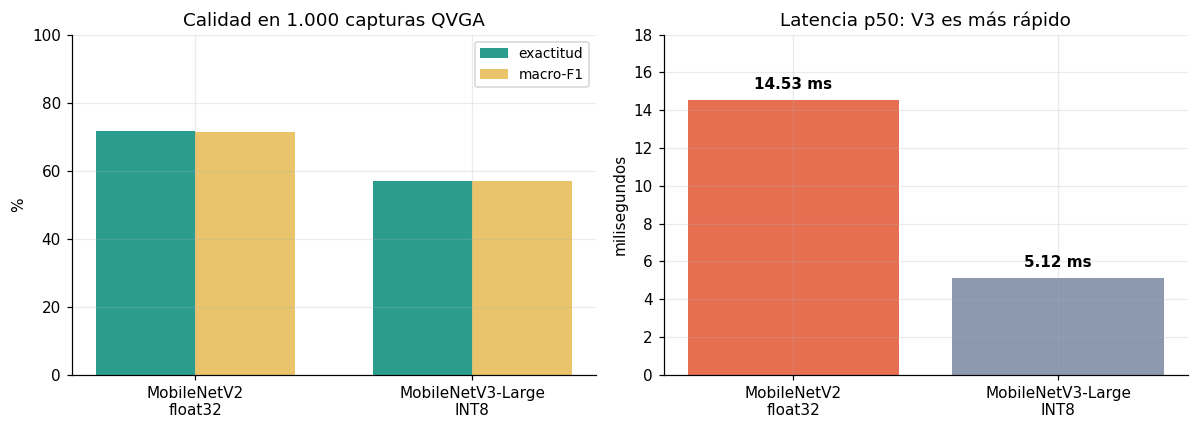

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

VIDRIO, PLASTICO, GRIS, ALERTA = '#2a9d8f', '#e9c46a', '#8d99ae', '#e76f51'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
modelos = ['MobileNetV2\nfloat32', 'MobileNetV3-Large\nINT8']
exactitud = [71.60, 57.10]
macro_f1 = [71.25, 57.09]
latencia = [14.53, 5.12]
x = np.arange(2)
ax1.bar(x - .18, exactitud, .36, label='exactitud', color=VIDRIO)
ax1.bar(x + .18, macro_f1, .36, label='macro-F1', color=PLASTICO)
ax1.set_xticks(x); ax1.set_xticklabels(modelos); ax1.set(ylabel='%', ylim=(0, 100), title='Calidad en 1.000 capturas QVGA'); ax1.legend(fontsize=9)
ax2.bar(modelos, latencia, color=[ALERTA, GRIS]); ax2.set(ylabel='milisegundos', ylim=(0, 18), title='Latencia p50: V3 es más rápido')
for i, value in enumerate(latencia): ax2.text(i, value + .6, f'{value:.2f} ms', ha='center', weight='bold')
plt.tight_layout(); plt.show()


## La consecuencia práctica

Hay que medir el **artefacto que se desplegará** en el dominio donde trabajará. MobileNetV3-Large ganó validación Keras float32, pero su TFLite INT8 obtuvo 57,10 % en 1.000 capturas OV3660/QVGA; MobileNetV2 TFLite float32 obtuvo 71,60 % con el mismo pipeline.

Por esa comparación se activó el 13 de agosto de 2026 `run_20260721_2129`. Su hash esperado es `da71c12244076c1fe8f206a444f0c7fad9af467f813976acd40e027ae62f56b1`. MobileNetV3-Large INT8 permanece en `model/backups/`, auditado y sin voto.


## Integración segura

El protocolo para probar un candidato sin arriesgar el robot:

1. Exportar el TFLite con el preprocesamiento incluido
   ([07](07-transfer-learning-y-mobilenet.ipynb)).
2. Conservar exactamente las etiquetas `plastico` y `vidrio` — `local_model.py`
   rechaza cualquier otra lista.
3. Cargarlo por variable de entorno, **sin sobrescribir** `model.tflite`:

```bash
LOCAL_MODEL_PATH=model/runs/<corrida>/model.tflite
LOCAL_MODEL_LABELS=model/runs/<corrida>/labels.txt
```

4. Ejecutar las pruebas del servicio y de votación.
5. Desplegar en **modo sombra**: registrar su predicción sin dejar que cambie la
   decisión del robot.
6. Comparar todas las señales sobre las mismas capturas.
7. Cambiar la política de voto solo después de aprobar las métricas.

El modo sombra del paso 5 es la idea que cierra el círculo de toda la serie:
antes de confiar en un modelo, se le deja opinar sin consecuencias y se comprueba
si tenía razón.



## El resumen de la serie

Si hay que quedarse con cinco frases:

1. El error tiene costo físico, así que **abstenerse es barato y equivocarse es
   caro**.
2. Sistema experto y red neuronal **fallan por motivos distintos**, y por eso se
   combinan.
3. Una métrica solo vale si se midió en el **dominio real** del robot.
4. La **confianza de una red no mide si tiene razón**.
5. Hay que medir el **artefacto que se despliega**, no el modelo que se entrenó.

---

← [Cómo se mide](11-como-se-mide.ipynb) · [Índice](00-indice.ipynb)
